In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load Dataset
df = pd.read_csv("C:/Users/User/Downloads/Data Science/Extended_Employee_Performance_and_Productivity_Data.csv")
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


In [4]:
df.isnull().sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

In [5]:
df = df.drop(columns=["Employee_ID","Hire_Date"])

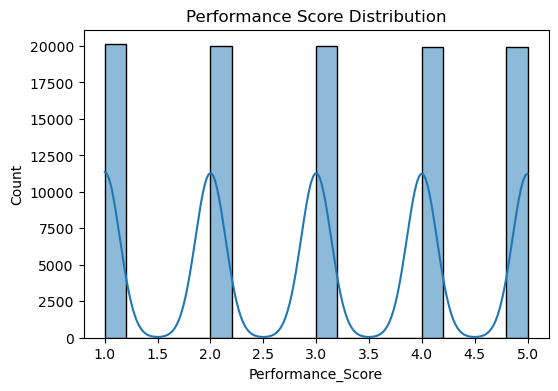

In [6]:
# Distribution of Performance Score
plt.figure(figsize=(6,4))

sns.histplot(df['Performance_Score'], bins=20, kde=True)

plt.title("Performance Score Distribution")

plt.show()

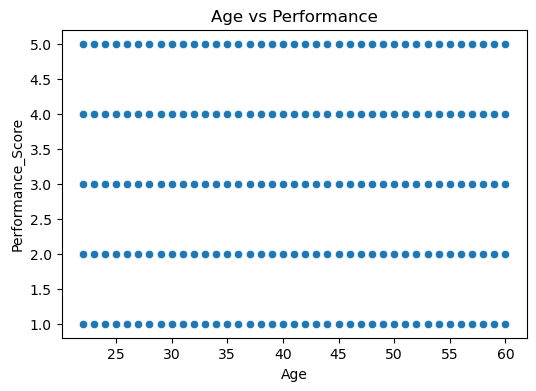

In [7]:
# Age vs Performance
plt.figure(figsize=(6,4))

sns.scatterplot(x='Age', y='Performance_Score', data=df)

plt.title("Age vs Performance")

plt.show()

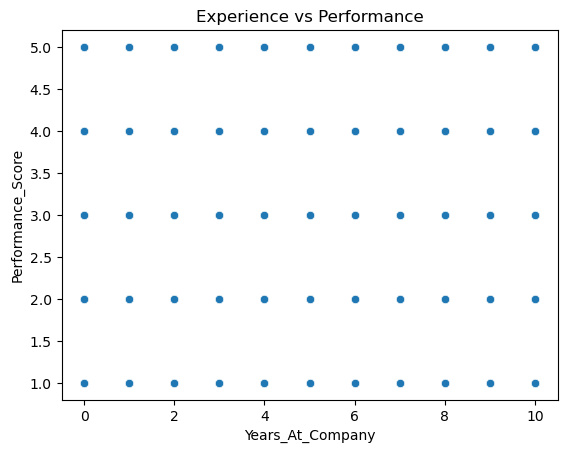

In [9]:
# Experience vs Performance
plt.figure(figsize=(6,4))

sns.scatterplot(x='Years_At_Company', y='Performance_Score', data=df)

plt.title("Experience vs Performance")

plt.show()

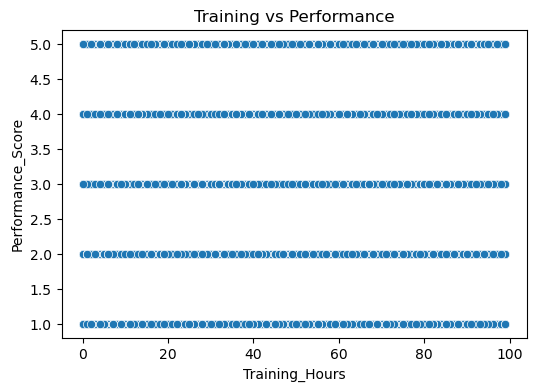

In [10]:
# Training Hours vs Performance
plt.figure(figsize=(6,4))

sns.scatterplot(x='Training_Hours', y='Performance_Score', data=df)

plt.title("Training vs Performance")

plt.show()

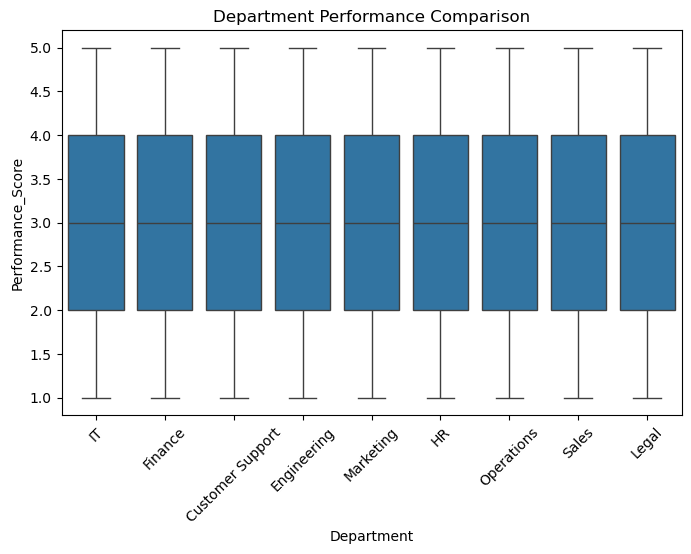

In [11]:
# Department vs Performance
plt.figure(figsize=(8,5))

sns.boxplot(x='Department', y='Performance_Score', data=df)

plt.xticks(rotation=45)

plt.title("Department Performance Comparison")

plt.show()

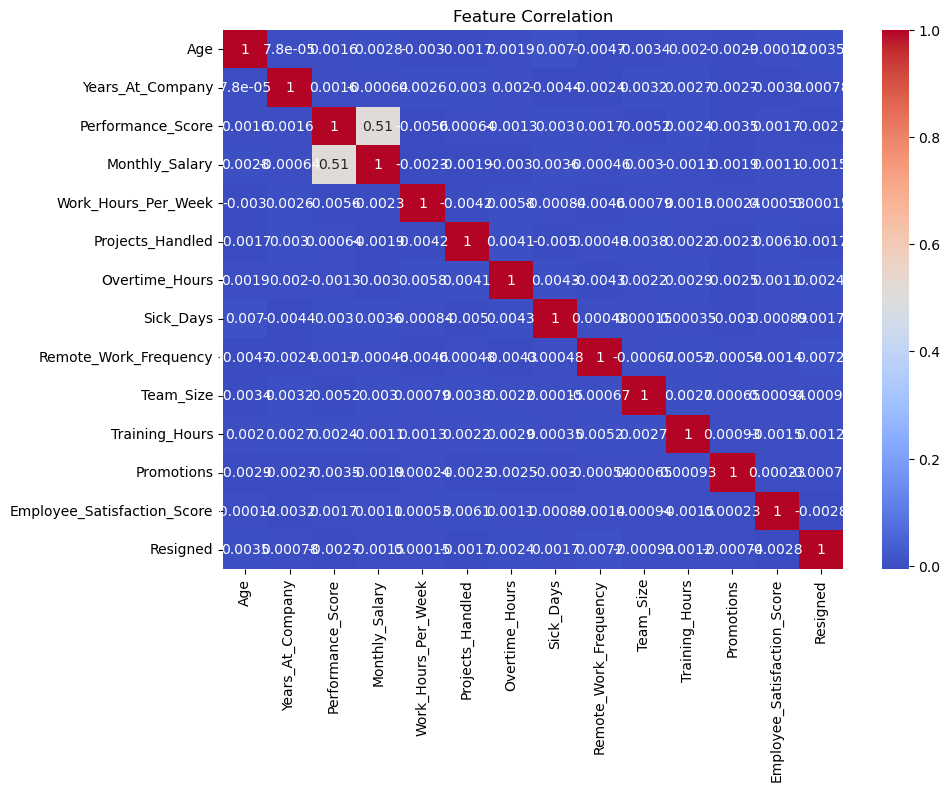

In [12]:
# Correlation Heatmap
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [14]:
# Feature Engineering
df = pd.get_dummies(df, columns=[
    "Department",
    "Gender",
    "Job_Title",
    "Education_Level"
], drop_first=True)

In [15]:
# Define Features and Target
X = df.drop("Performance_Score", axis=1)
y = df["Performance_Score"]

In [16]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
# Prediction
y_pred = model.predict(X_test)

In [19]:
# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.06436140277258517
R2 Score: 0.9678992449022632


In [21]:
# Prediction Example
# Select multiple employees from X_test (e.g., first 5 rows)
existing_employees = X_test.iloc[0:5]

# Predict
predicted_scores = model.predict(existing_employees)

# Get actual scores
actual_scores = y_test.iloc[0:5]

# Show results
results = pd.DataFrame({
    "Predicted_Score": predicted_scores.round(2),
    "Actual_Score": actual_scores.values
})

print(results)

   Predicted_Score  Actual_Score
0             1.82             2
1             4.17             4
2             3.00             3
3             1.43             1
4             3.68             4
